
=== Scheme: heun ===
dt =  1200.0 s | RMS error = 1.048062e+03 m | p(dt->dt/2) = 2.0022
dt =   600.0 s | RMS error = 2.616158e+02 m | p(dt->dt/2) = 2.0005
dt =   300.0 s | RMS error = 6.537957e+01 m | p(dt->dt/2) = 2.0000
dt =   150.0 s | RMS error = 1.634524e+01 m | p(dt->dt/2) = 1.9968
dt =    75.0 s | RMS error = 4.095371e+00 m

=== Scheme: midpoint ===
dt =  1200.0 s | RMS error = 1.048062e+03 m | p(dt->dt/2) = 2.0022
dt =   600.0 s | RMS error = 2.616158e+02 m | p(dt->dt/2) = 2.0005
dt =   300.0 s | RMS error = 6.537947e+01 m | p(dt->dt/2) = 1.9999
dt =   150.0 s | RMS error = 1.634604e+01 m | p(dt->dt/2) = 1.9973
dt =    75.0 s | RMS error = 4.094219e+00 m


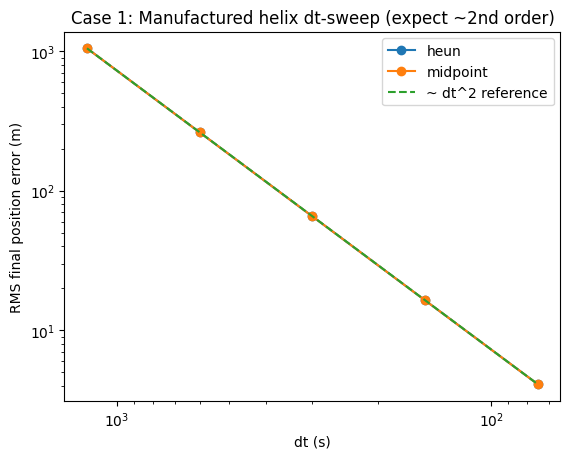

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# === 1) import 你的追踪函数 ===
# 方式A：如果你跟 test.ipynb 一样
# import sys
# sys.path.append("src/lagranto_tracking")
# from lagranto_track import track_particles_heun, track_particles_midpoint

# 方式B：如果 lagranto_track.py 就在当前目录
from lagranto_track import (
    track_particles_heun,
    track_particles_midpoint,
)

# ============================================================
# 2) Case 1: 显式 helix 制造解参数
# ============================================================
R = 3396200.0  # Mars-like radius (m)

T_period = 21600.0                 # 6 hours
Omega = 2.0 * np.pi / T_period     # rad/s

t_end = 18000.0  # 5 hours = 5/6 period (关键：避免整周期误差抵消)

A_deg = 2.0      # latitude amplitude in degree (小幅摆动，降低空间插值误差)
A = np.deg2rad(A_deg)

W = 0.2          # vertical velocity (m/s)

dt_list = [1200.0, 600.0, 300.0, 150.0, 75.0]  # dt sweep, halving

# ============================================================
# 3) 空间网格：经度可粗（但要覆盖全球+含重复端点），纬度要足够细
# ============================================================
lon_grid = np.arange(0.0, 361.0, 20.0)         # 0..360 include endpoint
lat_grid = np.linspace(-5.0, 5.0, 401)         # 0.025 deg step
alt_grid = np.linspace(0.0, 20000.0, 11)       # m

lower_boundary = float(alt_grid.min())
upper_boundary = float(alt_grid.max())

# ============================================================
# 4) 粒子初始点（lon, lat in degree; alt in m）
# ============================================================
init_points = [
    (350.0,  0.0,  5000.0),
    ( 10.0,  1.0,  8000.0),
    (180.0, -2.0, 10000.0),
]

# ============================================================
# 5) 制造解：解析轨迹 + 解析速度场
# ============================================================
def exact_helix(t, lon0_deg, lat0_deg, alt0_m):
    """
    t: scalar or array (s)
    return lon_deg, lat_deg, alt_m (same shape as t)
    """
    t = np.asarray(t, dtype=float)
    lon = lon0_deg + np.rad2deg(Omega * t)
    lat = lat0_deg + A_deg * np.sin(Omega * t)
    alt = alt0_m + W * t

    # wrap lon to [0,360)
    lon = lon % 360.0
    return lon, lat, alt

def build_wind_fields(time_s):
    """
    返回 u,v,w 三个四维数组，shape = (T, Z, Y, X)
    对齐 track_particles_* 需要的轴顺序: time, alt, lat, lon
    """
    time_s = np.asarray(time_s, dtype=float)
    Tn = time_s.size
    Zn = alt_grid.size
    Yn = lat_grid.size
    Xn = lon_grid.size

    # (Z,1,1)
    rho = (R + alt_grid)[:, None, None]

    # u depends on (alt, lat), independent of lon and time:
    lat_rad = np.deg2rad(lat_grid)[None, :, None]  # (1,Y,1)
    u_zy1 = rho * np.cos(lat_rad) * Omega          # (Z,Y,1)
    u_zyx = np.broadcast_to(u_zy1, (Zn, Yn, Xn))    # (Z,Y,X)

    u = np.empty((Tn, Zn, Yn, Xn), dtype=np.float64)
    u[:] = u_zyx[None, :, :, :]

    # v depends on (alt, time), independent of lat/lon:
    v = np.empty((Tn, Zn, Yn, Xn), dtype=np.float64)
    cos_term = np.cos(Omega * time_s)              # (T,)
    for it, c in enumerate(cos_term):
        v_z = (R + alt_grid) * (A * Omega * c)     # (Z,)
        v[it, :, :, :] = v_z[:, None, None]        # broadcast to (Z,Y,X)

    # w constant:
    w = np.full((Tn, Zn, Yn, Xn), W, dtype=np.float64)

    return u, v, w

# ============================================================
# 6) 误差度量：3D 物理距离（避免经度跨界造成假误差）
# ============================================================
def sph_to_xyz(lon_deg, lat_deg, alt_m):
    lon = np.deg2rad(lon_deg)
    lat = np.deg2rad(lat_deg)
    clat = np.cos(lat)
    r = R + alt_m
    x = r * clat * np.cos(lon)
    y = r * clat * np.sin(lon)
    z = r * np.sin(lat)
    return np.array([x, y, z], dtype=np.float64)

def rms_final_error(traj_list, t_end, scheme_name=""):
    """
    traj_list: track_particles_* 返回的 list[dict], 最后一个 dict 是 t_end 的位置
    """
    final_dict = traj_list[-1]
    errs = []
    for pid, (lon0, lat0, alt0) in enumerate(init_points):
        lon_true, lat_true, alt_true = exact_helix(t_end, lon0, lat0, alt0)
        lon_num,  lat_num,  alt_num  = final_dict[pid]

        e = np.linalg.norm(
            sph_to_xyz(lon_num, lat_num, alt_num) -
            sph_to_xyz(lon_true, lat_true, alt_true)
        )
        errs.append(e)

    errs = np.asarray(errs, dtype=float)
    return float(np.sqrt(np.mean(errs**2)))

def observed_order(errors, dts):
    """
    errors[i] corresponds to dts[i].
    Returns p[i] between i and i+1, using p = ln(Ei/Ei+1)/ln(dt_i/dt_i+1)
    """
    errors = np.asarray(errors, float)
    dts = np.asarray(dts, float)
    p = []
    for i in range(len(errors)-1):
        p_i = np.log(errors[i]/errors[i+1]) / np.log(dts[i]/dts[i+1])
        p.append(p_i)
    return np.asarray(p, float)

# ============================================================
# 7) dt sweep：Heun + implicit midpoint
# ============================================================
results = {}

for scheme in ["heun", "midpoint"]:
    errs = []

    for dt in dt_list:
        time = np.arange(0.0, t_end + dt, dt)  # 确保最后一个点是 t_end

        u, v, w = build_wind_fields(time)

        if scheme == "heun":
            traj = track_particles_heun(
                time=time,
                u_time_interp=u,
                v_time_interp=v,
                w_time_interp=w,
                need_track_initial_points=init_points,
                alt_grid_m=alt_grid,
                lat_grid=lat_grid,
                lon_grid=lon_grid,
                lower_boundary=lower_boundary,
                upper_boundary=upper_boundary,
                radius=R,
                verbose=False,
                w_positive_up=True,
                lon_mode=None,
                periodic_lon="auto",
            )
        else:
            traj = track_particles_midpoint(
                time=time,
                u_time_interp=u,
                v_time_interp=v,
                w_time_interp=w,
                need_track_initial_points=init_points,
                alt_grid_m=alt_grid,
                lat_grid=lat_grid,
                lon_grid=lon_grid,
                lower_boundary=lower_boundary,
                upper_boundary=upper_boundary,
                radius=R,
                verbose=False,
                w_positive_up=True,
                lon_mode=None,
                periodic_lon="auto",
                picard_iters=3,        # 若你想更“真隐式”，可加大到 5 或设置 picard_tol
                picard_tol=None,
                use_slerp_midpoint=True,
            )

        err = rms_final_error(traj, t_end)
        errs.append(err)

        # 释放大数组（避免循环累积占用）
        del u, v, w, traj

    p = observed_order(errs, dt_list)
    results[scheme] = (errs, p)

# ============================================================
# 8) 打印结果：误差 & observed order
# ============================================================
for scheme in ["heun", "midpoint"]:
    errs, p = results[scheme]
    print(f"\n=== Scheme: {scheme} ===")
    for i, dt in enumerate(dt_list):
        if i < len(dt_list) - 1:
            print(f"dt = {dt:7.1f} s | RMS error = {errs[i]:12.6e} m | p(dt->dt/2) = {p[i]:.4f}")
        else:
            print(f"dt = {dt:7.1f} s | RMS error = {errs[i]:12.6e} m")

# ============================================================
# 9) 画图：log-log 收敛（斜率≈2）
# ============================================================
plt.figure()
for scheme in ["heun", "midpoint"]:
    errs, _ = results[scheme]
    plt.loglog(dt_list, errs, marker="o", label=scheme)

# 参考线 ~ dt^2（用第一个点定标）
refC = results["heun"][0][0] / (dt_list[0]**2)
ref = [refC * (dt**2) for dt in dt_list]
plt.loglog(dt_list, ref, linestyle="--", label="~ dt^2 reference")

plt.gca().invert_xaxis()
plt.xlabel("dt (s)")
plt.ylabel("RMS final position error (m)")
plt.legend()
plt.title("Case 1: Manufactured helix dt-sweep (expect ~2nd order)")
plt.show()



=== Trajectory comparison metrics (dt_vis = 1200.0 s) ===
pid        init (lon, lat, alt_m)    Heun final/max error (m)    Midpoint final/max error (m)
0    ( 350.00,   0.00,   5000.0) 1.047241e+03 / 1.190795e+03 1.047241e+03 / 1.190795e+03
1    (  10.00,   1.00,   8000.0) 1.048164e+03 / 1.191844e+03 1.048164e+03 / 1.191844e+03
2    ( 180.00,  -2.00,  10000.0) 1.048779e+03 / 1.192544e+03 1.048779e+03 / 1.192544e+03


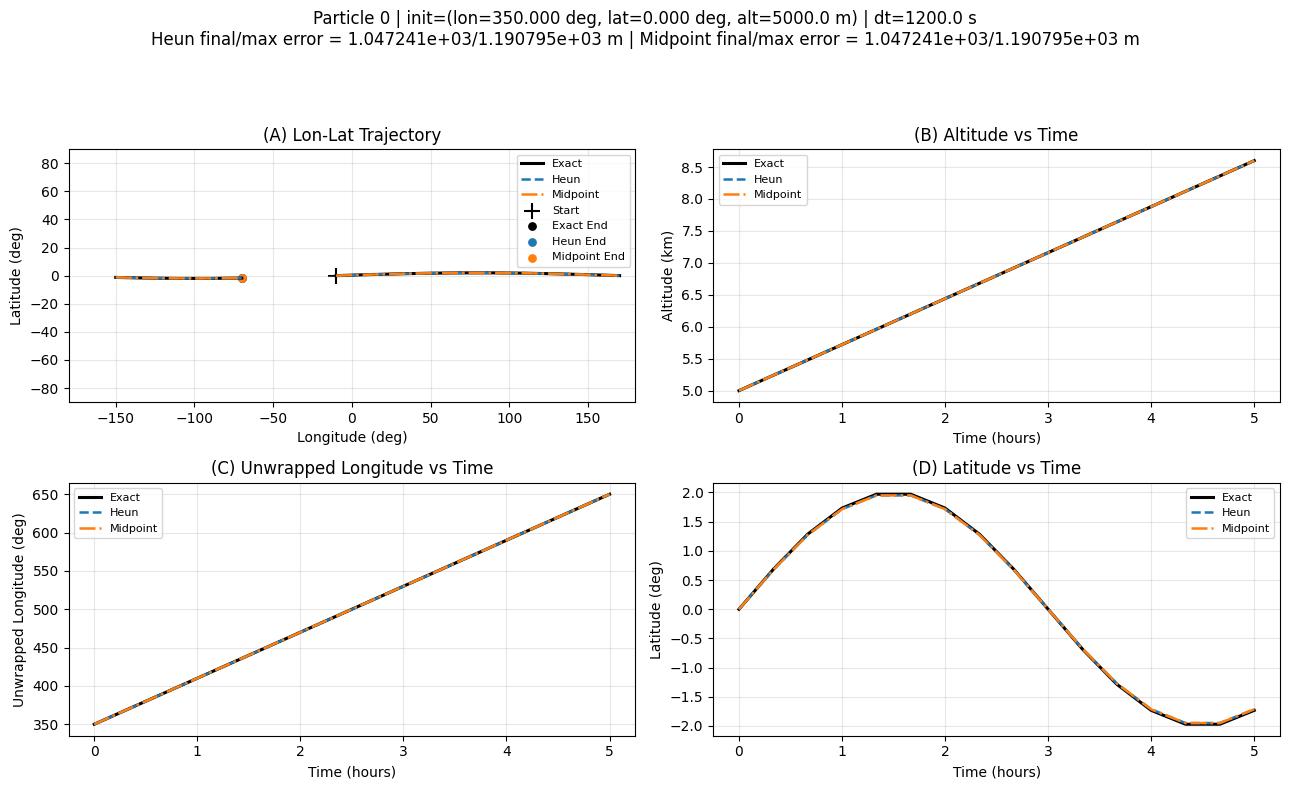

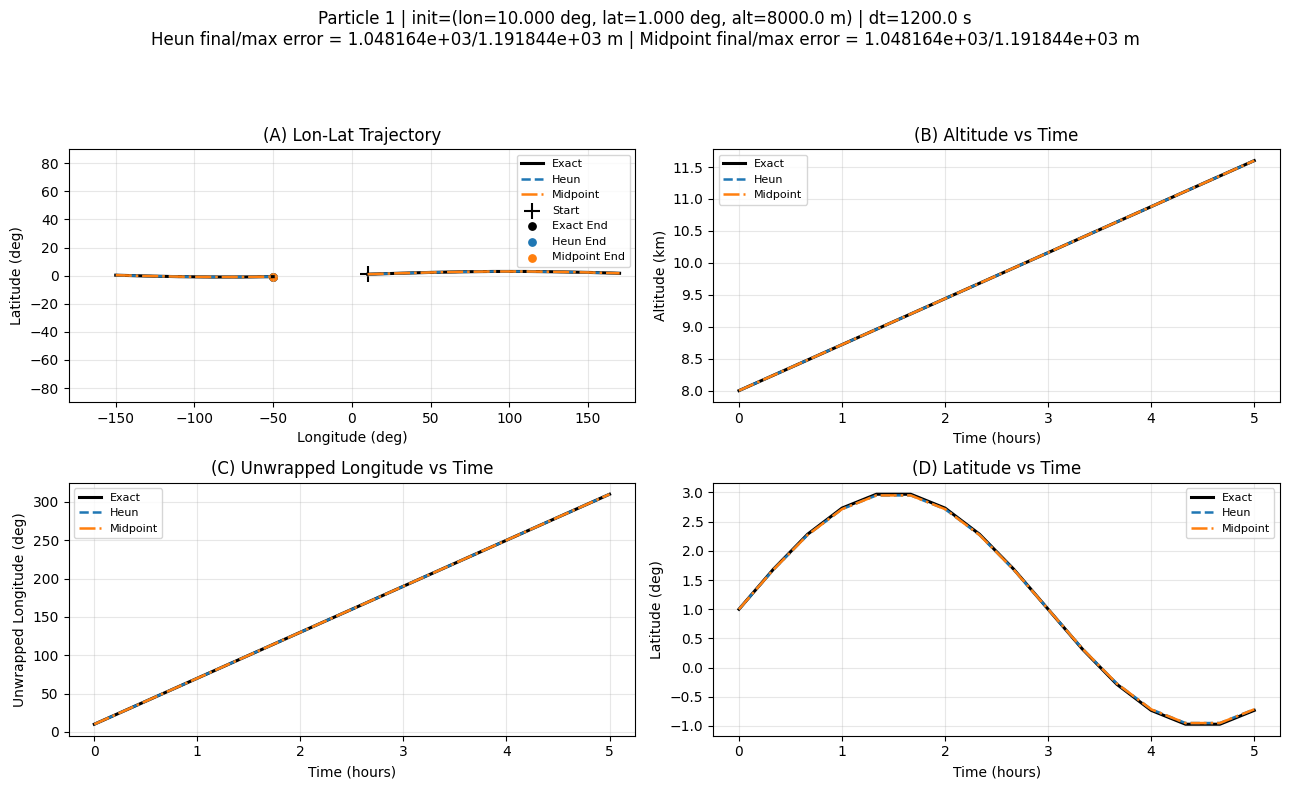

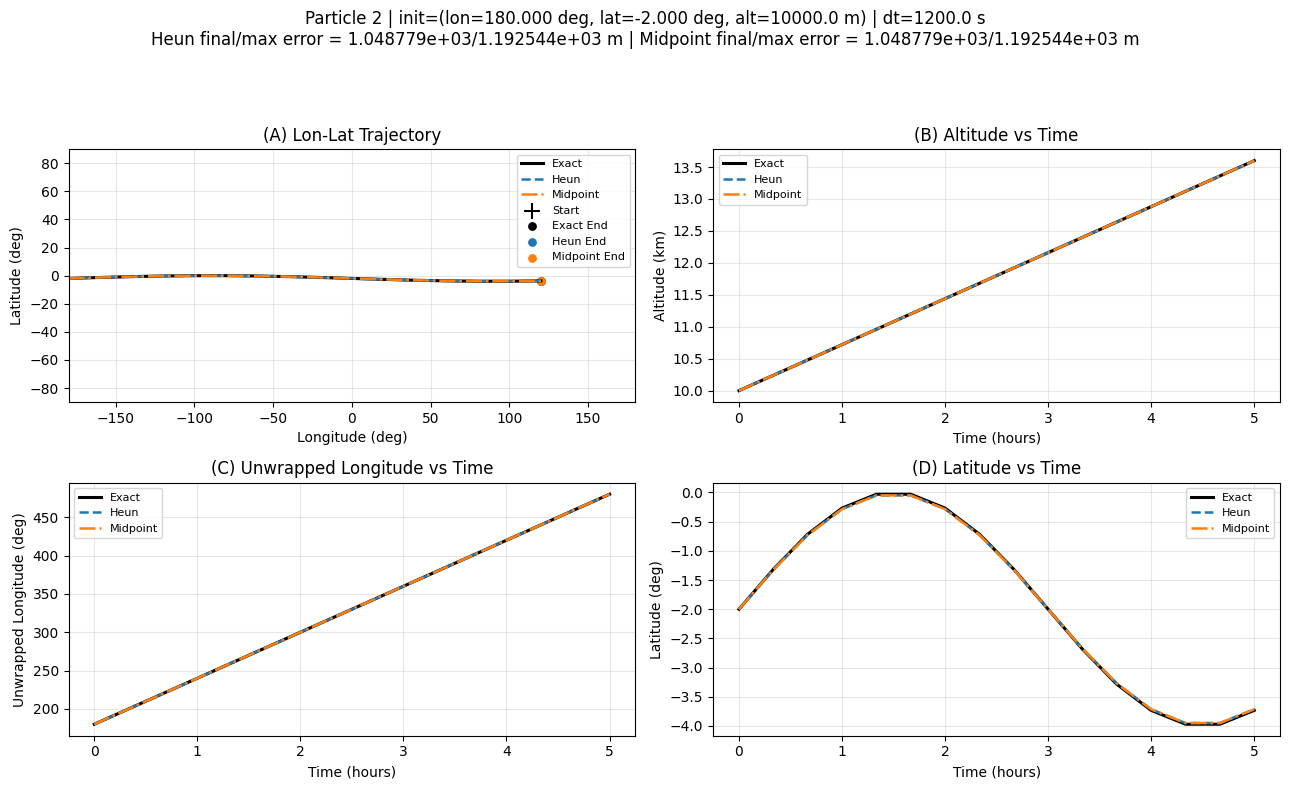

In [8]:
# ============================================================
# 10) 轨迹直观对比：解析解 vs Heun vs Implicit midpoint
# ============================================================

def make_time_grid(dt, t_end):
    """Create a strictly aligned time grid from 0 to t_end."""
    dt = float(dt)
    t_end = float(t_end)

    if (not np.isfinite(dt)) or dt <= 0.0:
        raise ValueError("dt must be finite and > 0")
    if (not np.isfinite(t_end)) or t_end < 0.0:
        raise ValueError("t_end must be finite and >= 0")

    n = int(np.round(t_end / dt))
    if abs(n * dt - t_end) > 1e-12:
        raise ValueError(
            f"t_end={t_end} is not aligned with dt={dt}; "
            "please choose dt so that t_end/dt is an integer"
        )

    return np.linspace(0.0, t_end, n + 1, dtype=np.float64)


def extract_particle_series(step_list, init_points, pid, include_initial=True):
    """Extract (lon, lat, alt) arrays for a particle id from list[dict] trajectory output."""
    if pid < 0 or pid >= len(init_points):
        raise IndexError(f"pid={pid} out of range for init_points")

    lon_vals = []
    lat_vals = []
    alt_vals = []

    if include_initial:
        lon0, lat0, alt0 = init_points[pid]
        lon_vals.append(float(lon0))
        lat_vals.append(float(lat0))
        alt_vals.append(float(alt0))

    for step in step_list:
        if pid not in step:
            lon_vals.append(np.nan)
            lat_vals.append(np.nan)
            alt_vals.append(np.nan)
            continue

        lon_i, lat_i, alt_i = step[pid]
        lon_vals.append(float(lon_i))
        lat_vals.append(float(lat_i))
        alt_vals.append(float(alt_i))

    return (
        np.asarray(lon_vals, dtype=np.float64),
        np.asarray(lat_vals, dtype=np.float64),
        np.asarray(alt_vals, dtype=np.float64),
    )


def wrap_to_180(lon_deg):
    lon_deg = np.asarray(lon_deg, dtype=np.float64)
    return ((lon_deg + 180.0) % 360.0) - 180.0


def unwrap_lon_deg(lon_deg):
    """Unwrap longitude (degree) on each finite contiguous segment."""
    lon_deg = np.asarray(lon_deg, dtype=np.float64)
    out = np.full_like(lon_deg, np.nan)

    finite = np.isfinite(lon_deg)
    if not np.any(finite):
        return out

    idx = np.where(finite)[0]
    block_starts = [idx[0]]
    block_ends = []

    for i in range(1, idx.size):
        if idx[i] != idx[i - 1] + 1:
            block_ends.append(idx[i - 1])
            block_starts.append(idx[i])
    block_ends.append(idx[-1])

    for b0, b1 in zip(block_starts, block_ends):
        seg = lon_deg[b0 : b1 + 1]
        out[b0 : b1 + 1] = np.rad2deg(np.unwrap(np.deg2rad(seg)))

    return out


def insert_dateline_breaks(lon180, lat):
    """Insert NaN at segment starts when lon jump > 180 deg to avoid false connecting lines."""
    lon_plot = np.asarray(lon180, dtype=np.float64).copy()
    lat_plot = np.asarray(lat, dtype=np.float64).copy()

    if lon_plot.shape != lat_plot.shape:
        raise ValueError("lon180 and lat must have the same shape")
    if lon_plot.size < 2:
        return lon_plot, lat_plot

    valid_pairs = (
        np.isfinite(lon_plot[:-1])
        & np.isfinite(lon_plot[1:])
        & np.isfinite(lat_plot[:-1])
        & np.isfinite(lat_plot[1:])
    )
    jumps = np.zeros(lon_plot.size - 1, dtype=bool)
    jumps[valid_pairs] = np.abs(lon_plot[1:][valid_pairs] - lon_plot[:-1][valid_pairs]) > 180.0

    cut_idx = np.where(jumps)[0] + 1
    lon_plot[cut_idx] = np.nan
    lat_plot[cut_idx] = np.nan

    return lon_plot, lat_plot


def sph_to_xyz_vec(lon_deg, lat_deg, alt_m):
    """Vectorized spherical to Cartesian conversion with radius R + altitude."""
    lon = np.deg2rad(np.asarray(lon_deg, dtype=np.float64))
    lat = np.deg2rad(np.asarray(lat_deg, dtype=np.float64))
    alt = np.asarray(alt_m, dtype=np.float64)

    r = R + alt
    clat = np.cos(lat)

    x = r * clat * np.cos(lon)
    y = r * clat * np.sin(lon)
    z = r * np.sin(lat)

    return np.column_stack((x, y, z))


def compute_path_error_m(num_series, exact_series):
    """Per-time-point 3D distance error (m)."""
    lon_num, lat_num, alt_num = [np.asarray(a, dtype=np.float64) for a in num_series]
    lon_ex, lat_ex, alt_ex = [np.asarray(a, dtype=np.float64) for a in exact_series]

    if lon_num.shape != lon_ex.shape:
        raise ValueError("num and exact series must have identical shape")

    err = np.full(lon_num.shape, np.nan, dtype=np.float64)
    finite = (
        np.isfinite(lon_num)
        & np.isfinite(lat_num)
        & np.isfinite(alt_num)
        & np.isfinite(lon_ex)
        & np.isfinite(lat_ex)
        & np.isfinite(alt_ex)
    )

    if np.any(finite):
        xyz_num = sph_to_xyz_vec(lon_num[finite], lat_num[finite], alt_num[finite])
        xyz_ex = sph_to_xyz_vec(lon_ex[finite], lat_ex[finite], alt_ex[finite])
        err[finite] = np.linalg.norm(xyz_num - xyz_ex, axis=1)

    return err


def _last_finite(arr):
    arr = np.asarray(arr, dtype=np.float64)
    idx = np.where(np.isfinite(arr))[0]
    if idx.size == 0:
        return np.nan
    return float(arr[idx[-1]])


def _max_finite(arr):
    arr = np.asarray(arr, dtype=np.float64)
    if not np.any(np.isfinite(arr)):
        return np.nan
    return float(np.nanmax(arr))


def plot_compare_particle(pid, time_s, exact, heun, midpoint, init_point, metrics):
    time_s = np.asarray(time_s, dtype=np.float64)
    if time_s.ndim != 1:
        raise ValueError("time_s must be 1-D")

    time_h = time_s / 3600.0

    lon_ex, lat_ex, alt_ex = exact
    lon_h, lat_h, alt_h = heun
    lon_m, lat_m, alt_m = midpoint

    # lon-lat plane in [-180, 180], with dateline-safe breaks
    lon_ex_180 = wrap_to_180(lon_ex)
    lon_h_180 = wrap_to_180(lon_h)
    lon_m_180 = wrap_to_180(lon_m)

    lon_ex_plot, lat_ex_plot = insert_dateline_breaks(lon_ex_180, lat_ex)
    lon_h_plot, lat_h_plot = insert_dateline_breaks(lon_h_180, lat_h)
    lon_m_plot, lat_m_plot = insert_dateline_breaks(lon_m_180, lat_m)

    # unwrapped longitudes for time series
    lon_ex_unwrap = unwrap_lon_deg(lon_ex)
    lon_h_unwrap = unwrap_lon_deg(lon_h)
    lon_m_unwrap = unwrap_lon_deg(lon_m)

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)

    # A) lon-lat trajectory plane
    ax = axes[0, 0]
    ax.plot(lon_ex_plot, lat_ex_plot, color="k", linestyle="-", linewidth=2.2, label="Exact")
    ax.plot(lon_h_plot, lat_h_plot, color="tab:blue", linestyle="--", linewidth=1.8, label="Heun")
    ax.plot(lon_m_plot, lat_m_plot, color="tab:orange", linestyle="-.", linewidth=1.8, label="Midpoint")

    start_lon_180 = wrap_to_180(np.array([init_point[0]], dtype=np.float64))[0]
    start_lat = float(init_point[1])
    ax.scatter([start_lon_180], [start_lat], color="k", marker="+", s=120, label="Start")

    for name, lon_arr, lat_arr, color in [
        ("Exact", lon_ex_180, lat_ex, "k"),
        ("Heun", lon_h_180, lat_h, "tab:blue"),
        ("Midpoint", lon_m_180, lat_m, "tab:orange"),
    ]:
        finite_idx = np.where(np.isfinite(lon_arr) & np.isfinite(lat_arr))[0]
        if finite_idx.size > 0:
            i_end = finite_idx[-1]
            ax.scatter([lon_arr[i_end]], [lat_arr[i_end]], color=color, marker="o", s=28, label=f"{name} End")

    ax.set_xlim(-180.0, 180.0)
    ax.set_ylim(-90.0, 90.0)
    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_title("(A) Lon-Lat Trajectory")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

    # B) altitude vs time
    ax = axes[0, 1]
    ax.plot(time_h, alt_ex / 1000.0, color="k", linestyle="-", linewidth=2.2, label="Exact")
    ax.plot(time_h, alt_h / 1000.0, color="tab:blue", linestyle="--", linewidth=1.8, label="Heun")
    ax.plot(time_h, alt_m / 1000.0, color="tab:orange", linestyle="-.", linewidth=1.8, label="Midpoint")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Altitude (km)")
    ax.set_title("(B) Altitude vs Time")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

    # C) unwrapped longitude vs time
    ax = axes[1, 0]
    ax.plot(time_h, lon_ex_unwrap, color="k", linestyle="-", linewidth=2.2, label="Exact")
    ax.plot(time_h, lon_h_unwrap, color="tab:blue", linestyle="--", linewidth=1.8, label="Heun")
    ax.plot(time_h, lon_m_unwrap, color="tab:orange", linestyle="-.", linewidth=1.8, label="Midpoint")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Unwrapped Longitude (deg)")
    ax.set_title("(C) Unwrapped Longitude vs Time")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

    # D) latitude vs time
    ax = axes[1, 1]
    ax.plot(time_h, lat_ex, color="k", linestyle="-", linewidth=2.2, label="Exact")
    ax.plot(time_h, lat_h, color="tab:blue", linestyle="--", linewidth=1.8, label="Heun")
    ax.plot(time_h, lat_m, color="tab:orange", linestyle="-.", linewidth=1.8, label="Midpoint")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_title("(D) Latitude vs Time")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

    dt_local = np.nan
    if time_s.size >= 2:
        dt_local = float(time_s[1] - time_s[0])

    fig.suptitle(
        "Particle {pid} | init=(lon={lon0:.3f} deg, lat={lat0:.3f} deg, alt={alt0:.1f} m) | dt={dt:.1f} s\n"
        "Heun final/max error = {hf:.6e}/{hm:.6e} m | "
        "Midpoint final/max error = {mf:.6e}/{mm:.6e} m".format(
            pid=pid,
            lon0=float(init_point[0]),
            lat0=float(init_point[1]),
            alt0=float(init_point[2]),
            dt=dt_local,
            hf=metrics["heun_final_error_m"],
            hm=metrics["heun_max_error_m"],
            mf=metrics["midpoint_final_error_m"],
            mm=metrics["midpoint_max_error_m"],
        )
    )

    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.92])
    plt.show()


# ---- 10.1 参数与轨迹数据生成 ----
dt_vis = 1200.0  # 放大差异

time_vis = make_time_grid(dt_vis, t_end)
u_vis, v_vis, w_vis = build_wind_fields(time_vis)

traj_heun_vis = track_particles_heun(
    time=time_vis,
    u_time_interp=u_vis,
    v_time_interp=v_vis,
    w_time_interp=w_vis,
    need_track_initial_points=init_points,
    alt_grid_m=alt_grid,
    lat_grid=lat_grid,
    lon_grid=lon_grid,
    lower_boundary=lower_boundary,
    upper_boundary=upper_boundary,
    radius=R,
    verbose=False,
    w_positive_up=True,
    lon_mode=None,
    periodic_lon="auto",
)

traj_mid_vis = track_particles_midpoint(
    time=time_vis,
    u_time_interp=u_vis,
    v_time_interp=v_vis,
    w_time_interp=w_vis,
    need_track_initial_points=init_points,
    alt_grid_m=alt_grid,
    lat_grid=lat_grid,
    lon_grid=lon_grid,
    lower_boundary=lower_boundary,
    upper_boundary=upper_boundary,
    radius=R,
    verbose=False,
    w_positive_up=True,
    lon_mode=None,
    periodic_lon="auto",
    picard_iters=3,
    picard_tol=None,
    use_slerp_midpoint=True,
)

if len(traj_heun_vis) != len(time_vis) - 1:
    raise ValueError("Heun step length mismatch with time grid")
if len(traj_mid_vis) != len(time_vis) - 1:
    raise ValueError("Midpoint step length mismatch with time grid")


# ---- 10.2 逐粒子误差与绘图数据整理 ----
compare_payload = {}
rows = []

for pid, init_point in enumerate(init_points):
    lon_ex, lat_ex, alt_ex = exact_helix(time_vis, *init_point)
    exact_series = (
        np.asarray(lon_ex, dtype=np.float64),
        np.asarray(lat_ex, dtype=np.float64),
        np.asarray(alt_ex, dtype=np.float64),
    )

    heun_series = extract_particle_series(traj_heun_vis, init_points, pid, include_initial=True)
    mid_series = extract_particle_series(traj_mid_vis, init_points, pid, include_initial=True)

    for name, series in [("heun", heun_series), ("midpoint", mid_series)]:
        if series[0].shape[0] != time_vis.shape[0]:
            raise ValueError(f"{name} series length mismatch for pid={pid}")

    heun_err = compute_path_error_m(heun_series, exact_series)
    mid_err = compute_path_error_m(mid_series, exact_series)

    metrics = {
        "heun_final_error_m": _last_finite(heun_err),
        "heun_max_error_m": _max_finite(heun_err),
        "midpoint_final_error_m": _last_finite(mid_err),
        "midpoint_max_error_m": _max_finite(mid_err),
    }

    compare_payload[pid] = {
        "init_point": init_point,
        "exact": exact_series,
        "heun": heun_series,
        "midpoint": mid_series,
        "heun_err": heun_err,
        "mid_err": mid_err,
        "metrics": metrics,
    }

    rows.append((pid, init_point, metrics))


# ---- 10.3 输出简短误差表 ----
print("\n=== Trajectory comparison metrics (dt_vis = {:.1f} s) ===".format(dt_vis))
print(
    "{:<4s} {:>28s} {:>27s} {:>31s}".format(
        "pid", "init (lon, lat, alt_m)", "Heun final/max error (m)", "Midpoint final/max error (m)"
    )
)
for pid, init_point, m in rows:
    print(
        "{:<4d} ({:7.2f}, {:6.2f}, {:8.1f}) {:>12.6e} / {:>12.6e} {:>12.6e} / {:>12.6e}".format(
            pid,
            float(init_point[0]),
            float(init_point[1]),
            float(init_point[2]),
            m["heun_final_error_m"],
            m["heun_max_error_m"],
            m["midpoint_final_error_m"],
            m["midpoint_max_error_m"],
        )
    )


# ---- 10.4 每粒子一页：2x2 轨迹对比图 ----
for pid in range(len(init_points)):
    payload = compare_payload[pid]
    plot_compare_particle(
        pid=pid,
        time_s=time_vis,
        exact=payload["exact"],
        heun=payload["heun"],
        midpoint=payload["midpoint"],
        init_point=payload["init_point"],
        metrics=payload["metrics"],
    )




=== 3D visualization run metrics (dt_3d = 300.0 s, t_end_3d = 18.0 h) ===
pid        init (lon, lat, alt_m)    Heun final/max error (m)    Midpoint final/max error (m)
0    ( 350.00,   0.00,   5000.0) 9.664978e-01 / 7.562272e+01 8.918124e-01 / 7.562194e+01
1    (  10.00,   1.00,   8000.0) 9.671998e-01 / 7.568919e+01 8.921776e-01 / 7.568839e+01
2    ( 180.00,  -2.00,  10000.0) 9.673236e-01 / 7.573348e+01 9.163343e-01 / 7.573298e+01


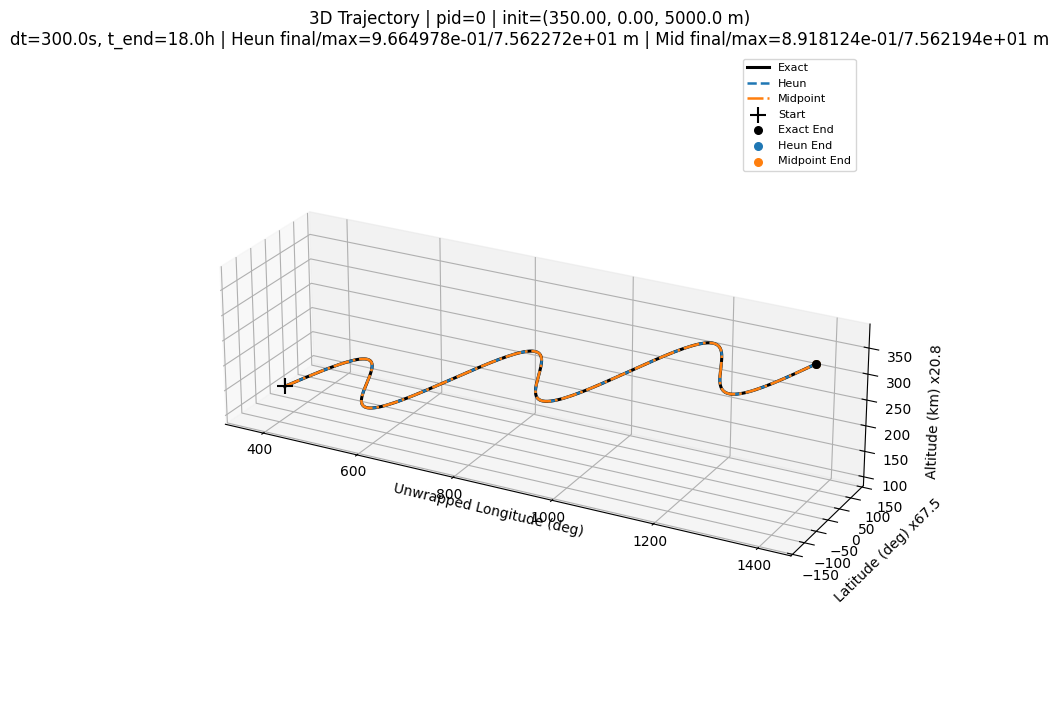

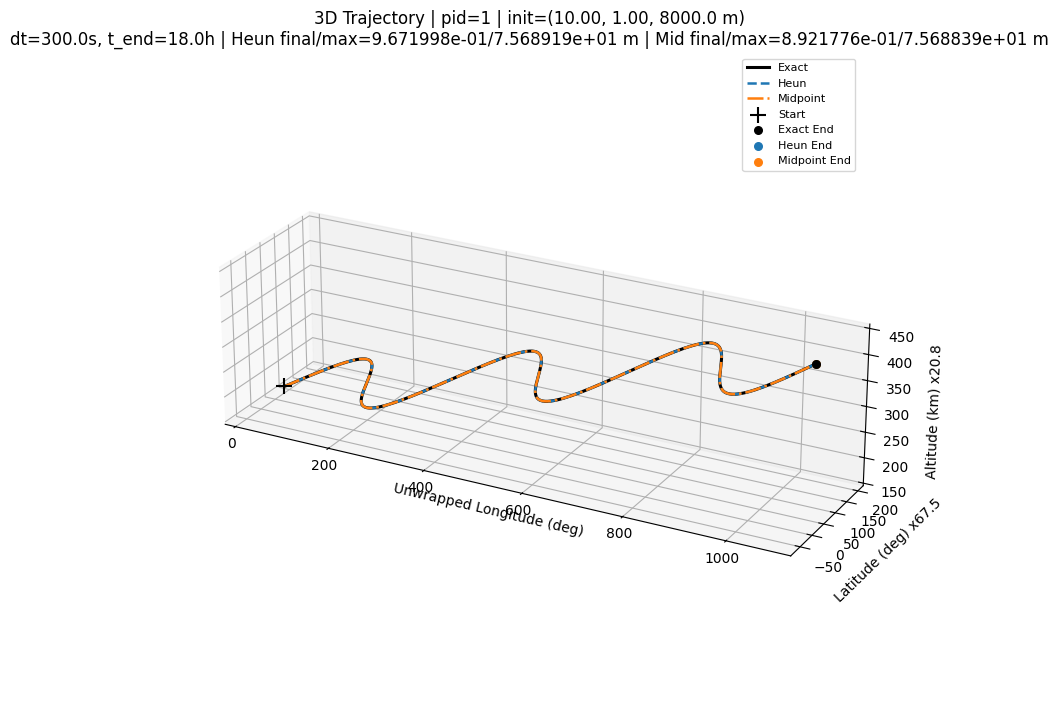

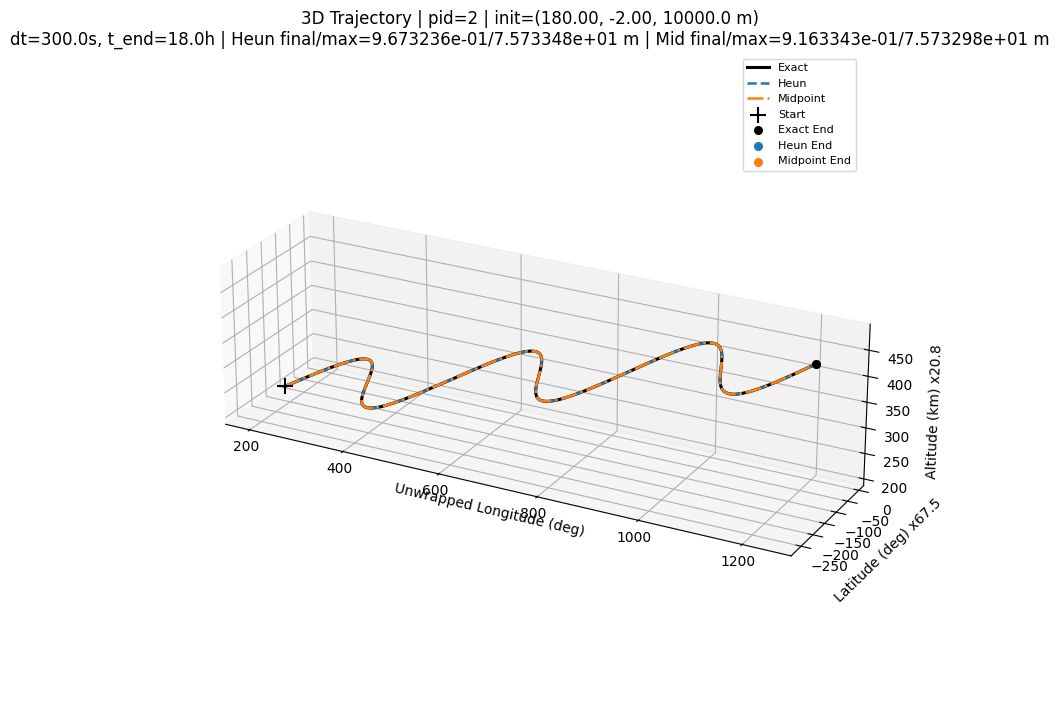

In [9]:
# ============================================================
# 11) 更直观的 3D 轨迹对比：Exact vs Heun vs Midpoint
# ============================================================


def build_wind_fields_for_grid(time_s, alt_grid_local, lat_grid_local, lon_grid_local):
    """
    Build manufactured wind fields on a user-provided grid.
    Output shapes: (T, Z, Y, X) aligned with track_particles_* expectations.
    """
    time_s = np.asarray(time_s, dtype=np.float64)
    alt_grid_local = np.asarray(alt_grid_local, dtype=np.float64)
    lat_grid_local = np.asarray(lat_grid_local, dtype=np.float64)
    lon_grid_local = np.asarray(lon_grid_local, dtype=np.float64)

    Tn = time_s.size
    Zn = alt_grid_local.size
    Yn = lat_grid_local.size
    Xn = lon_grid_local.size

    rho = (R + alt_grid_local)[:, None, None]  # (Z,1,1)

    lat_rad = np.deg2rad(lat_grid_local)[None, :, None]  # (1,Y,1)
    u_zy1 = rho * np.cos(lat_rad) * Omega  # (Z,Y,1)
    u_zyx = np.broadcast_to(u_zy1, (Zn, Yn, Xn))  # (Z,Y,X)

    u = np.empty((Tn, Zn, Yn, Xn), dtype=np.float64)
    u[:] = u_zyx[None, :, :, :]

    v = np.empty((Tn, Zn, Yn, Xn), dtype=np.float64)
    cos_term = np.cos(Omega * time_s)
    for it, c in enumerate(cos_term):
        v_z = (R + alt_grid_local) * (A * Omega * c)  # (Z,)
        v[it, :, :, :] = v_z[:, None, None]

    w = np.full((Tn, Zn, Yn, Xn), W, dtype=np.float64)

    return u, v, w


def _combined_range(*arrays):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=np.float64)
        finite = np.isfinite(arr)
        if np.any(finite):
            vals.append(arr[finite])
    if not vals:
        return np.nan
    merged = np.concatenate(vals)
    return float(np.nanmax(merged) - np.nanmin(merged))


def _combined_limits(*arrays, pad_frac=0.06, min_span=1.0):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=np.float64)
        finite = np.isfinite(arr)
        if np.any(finite):
            vals.append(arr[finite])

    if not vals:
        return (-1.0, 1.0)

    merged = np.concatenate(vals)
    vmin = float(np.nanmin(merged))
    vmax = float(np.nanmax(merged))

    span = vmax - vmin
    if span < min_span:
        center = 0.5 * (vmax + vmin)
        half = 0.5 * min_span
        vmin = center - half
        vmax = center + half
        span = min_span

    pad = pad_frac * span
    return (vmin - pad, vmax + pad)


def _safe_last_xyz(x, y, z):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    z = np.asarray(z, dtype=np.float64)
    idx = np.where(np.isfinite(x) & np.isfinite(y) & np.isfinite(z))[0]
    if idx.size == 0:
        return (np.nan, np.nan, np.nan)
    i = idx[-1]
    return (float(x[i]), float(y[i]), float(z[i]))


def plot_compare_particle_3d(
    pid,
    time_s,
    exact,
    heun,
    midpoint,
    init_point,
    metrics,
    scaling="enhanced",
):
    time_s = np.asarray(time_s, dtype=np.float64)
    if time_s.ndim != 1:
        raise ValueError("time_s must be 1-D")

    lon_ex, lat_ex, alt_ex = exact
    lon_h, lat_h, alt_h = heun
    lon_m, lat_m, alt_m = midpoint

    # 3D coordinates definition: x=unwrapped lon (deg), y=lat (deg), z=alt (km)
    x_ex = unwrap_lon_deg(lon_ex)
    x_h = unwrap_lon_deg(lon_h)
    x_m = unwrap_lon_deg(lon_m)

    y_ex = np.asarray(lat_ex, dtype=np.float64)
    y_h = np.asarray(lat_h, dtype=np.float64)
    y_m = np.asarray(lat_m, dtype=np.float64)

    z_ex = np.asarray(alt_ex, dtype=np.float64) / 1000.0
    z_h = np.asarray(alt_h, dtype=np.float64) / 1000.0
    z_m = np.asarray(alt_m, dtype=np.float64) / 1000.0

    lat_gain = 1.0
    alt_gain = 1.0

    if scaling == "enhanced":
        x_rng = _combined_range(x_ex, x_h, x_m)
        y_rng = _combined_range(y_ex, y_h, y_m)
        z_rng = _combined_range(z_ex, z_h, z_m)

        target = x_rng * 0.25 if np.isfinite(x_rng) and x_rng > 0.0 else 1.0

        lat_gain = float(np.clip(target / max(y_rng, 1e-9), 1.0, 120.0))
        alt_gain = float(np.clip(target / max(z_rng, 1e-9), 1.0, 120.0))

    y_ex_vis = y_ex * lat_gain
    y_h_vis = y_h * lat_gain
    y_m_vis = y_m * lat_gain

    z_ex_vis = z_ex * alt_gain
    z_h_vis = z_h * alt_gain
    z_m_vis = z_m * alt_gain

    fig = plt.figure(figsize=(10.5, 8.0))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(x_ex, y_ex_vis, z_ex_vis, color="k", linestyle="-", linewidth=2.2, label="Exact")
    ax.plot(x_h, y_h_vis, z_h_vis, color="tab:blue", linestyle="--", linewidth=1.8, label="Heun")
    ax.plot(x_m, y_m_vis, z_m_vis, color="tab:orange", linestyle="-.", linewidth=1.8, label="Midpoint")

    # start marker
    x_start = float(x_ex[0]) if np.isfinite(x_ex[0]) else np.nan
    y_start = float(y_ex_vis[0]) if np.isfinite(y_ex_vis[0]) else np.nan
    z_start = float(z_ex_vis[0]) if np.isfinite(z_ex_vis[0]) else np.nan
    if np.isfinite(x_start) and np.isfinite(y_start) and np.isfinite(z_start):
        ax.scatter([x_start], [y_start], [z_start], color="k", marker="+", s=120, label="Start")

    # end markers
    ex_end = _safe_last_xyz(x_ex, y_ex_vis, z_ex_vis)
    he_end = _safe_last_xyz(x_h, y_h_vis, z_h_vis)
    mi_end = _safe_last_xyz(x_m, y_m_vis, z_m_vis)

    if np.all(np.isfinite(ex_end)):
        ax.scatter([ex_end[0]], [ex_end[1]], [ex_end[2]], color="k", marker="o", s=30, label="Exact End")
    if np.all(np.isfinite(he_end)):
        ax.scatter([he_end[0]], [he_end[1]], [he_end[2]], color="tab:blue", marker="o", s=30, label="Heun End")
    if np.all(np.isfinite(mi_end)):
        ax.scatter([mi_end[0]], [mi_end[1]], [mi_end[2]], color="tab:orange", marker="o", s=30, label="Midpoint End")

    xlim = _combined_limits(x_ex, x_h, x_m, pad_frac=0.03, min_span=5.0)
    ylim = _combined_limits(y_ex_vis, y_h_vis, y_m_vis, pad_frac=0.08, min_span=1.0)
    zlim = _combined_limits(z_ex_vis, z_h_vis, z_m_vis, pad_frac=0.08, min_span=1.0)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)

    xspan = max(xlim[1] - xlim[0], 1e-9)
    yspan = max(ylim[1] - ylim[0], 1e-9)
    zspan = max(zlim[1] - zlim[0], 1e-9)
    try:
        ax.set_box_aspect((xspan, yspan, zspan))
    except Exception:
        pass

    ax.set_xlabel("Unwrapped Longitude (deg)")
    ax.set_ylabel(f"Latitude (deg) x{lat_gain:.1f}")
    ax.set_zlabel(f"Altitude (km) x{alt_gain:.1f}")

    dt_local = np.nan
    if time_s.size >= 2:
        dt_local = float(time_s[1] - time_s[0])

    ax.set_title(
        "3D Trajectory | pid={pid} | init=({lon:.2f}, {lat:.2f}, {alt:.1f} m)\n"
        "dt={dt:.1f}s, t_end={tend:.1f}h | "
        "Heun final/max={hf:.6e}/{hm:.6e} m | Mid final/max={mf:.6e}/{mm:.6e} m".format(
            pid=pid,
            lon=float(init_point[0]),
            lat=float(init_point[1]),
            alt=float(init_point[2]),
            dt=dt_local,
            tend=float(time_s[-1] / 3600.0),
            hf=metrics["heun_final_error_m"],
            hm=metrics["heun_max_error_m"],
            mf=metrics["midpoint_final_error_m"],
            mm=metrics["midpoint_max_error_m"],
        )
    )

    ax.view_init(elev=24, azim=-62)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

    plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.92])
    plt.show()


# ---- 11.1 3D 参数与数据准备 ----
dt_3d = 300.0
t_end_3d = 18.0 * 3600.0
time_3d = make_time_grid(dt_3d, t_end_3d)

alt_grid_3d = np.linspace(0.0, 30000.0, 16, dtype=np.float64)
lat_grid_3d = lat_grid
lon_grid_3d = lon_grid
lower_boundary_3d = 0.0
upper_boundary_3d = 30000.0

u_3d, v_3d, w_3d = build_wind_fields_for_grid(time_3d, alt_grid_3d, lat_grid_3d, lon_grid_3d)

traj_heun_3d = track_particles_heun(
    time=time_3d,
    u_time_interp=u_3d,
    v_time_interp=v_3d,
    w_time_interp=w_3d,
    need_track_initial_points=init_points,
    alt_grid_m=alt_grid_3d,
    lat_grid=lat_grid_3d,
    lon_grid=lon_grid_3d,
    lower_boundary=lower_boundary_3d,
    upper_boundary=upper_boundary_3d,
    radius=R,
    verbose=False,
    w_positive_up=True,
    lon_mode=None,
    periodic_lon="auto",
)

traj_mid_3d = track_particles_midpoint(
    time=time_3d,
    u_time_interp=u_3d,
    v_time_interp=v_3d,
    w_time_interp=w_3d,
    need_track_initial_points=init_points,
    alt_grid_m=alt_grid_3d,
    lat_grid=lat_grid_3d,
    lon_grid=lon_grid_3d,
    lower_boundary=lower_boundary_3d,
    upper_boundary=upper_boundary_3d,
    radius=R,
    verbose=False,
    w_positive_up=True,
    lon_mode=None,
    periodic_lon="auto",
    picard_iters=3,
    picard_tol=None,
    use_slerp_midpoint=True,
)

if len(traj_heun_3d) != len(time_3d) - 1:
    raise ValueError("3D Heun step length mismatch with time_3d")
if len(traj_mid_3d) != len(time_3d) - 1:
    raise ValueError("3D Midpoint step length mismatch with time_3d")


# ---- 11.2 3D run 误差整理 ----
compare_payload_3d = {}
rows_3d = []

for pid, init_point in enumerate(init_points):
    lon_ex, lat_ex, alt_ex = exact_helix(time_3d, *init_point)
    exact_series = (
        np.asarray(lon_ex, dtype=np.float64),
        np.asarray(lat_ex, dtype=np.float64),
        np.asarray(alt_ex, dtype=np.float64),
    )

    heun_series = extract_particle_series(traj_heun_3d, init_points, pid, include_initial=True)
    mid_series = extract_particle_series(traj_mid_3d, init_points, pid, include_initial=True)

    if heun_series[0].shape[0] != time_3d.shape[0]:
        raise ValueError(f"3D Heun series length mismatch for pid={pid}")
    if mid_series[0].shape[0] != time_3d.shape[0]:
        raise ValueError(f"3D Midpoint series length mismatch for pid={pid}")

    heun_err = compute_path_error_m(heun_series, exact_series)
    mid_err = compute_path_error_m(mid_series, exact_series)

    metrics = {
        "heun_final_error_m": _last_finite(heun_err),
        "heun_max_error_m": _max_finite(heun_err),
        "midpoint_final_error_m": _last_finite(mid_err),
        "midpoint_max_error_m": _max_finite(mid_err),
    }

    compare_payload_3d[pid] = {
        "init_point": init_point,
        "exact": exact_series,
        "heun": heun_series,
        "midpoint": mid_series,
        "heun_err": heun_err,
        "mid_err": mid_err,
        "metrics": metrics,
    }
    rows_3d.append((pid, init_point, metrics))


# ---- 11.3 3D run 误差摘要 ----
print("\n=== 3D visualization run metrics (dt_3d = {:.1f} s, t_end_3d = {:.1f} h) ===".format(dt_3d, t_end_3d / 3600.0))
print(
    "{:<4s} {:>28s} {:>27s} {:>31s}".format(
        "pid", "init (lon, lat, alt_m)", "Heun final/max error (m)", "Midpoint final/max error (m)"
    )
)
for pid, init_point, m in rows_3d:
    print(
        "{:<4d} ({:7.2f}, {:6.2f}, {:8.1f}) {:>12.6e} / {:>12.6e} {:>12.6e} / {:>12.6e}".format(
            pid,
            float(init_point[0]),
            float(init_point[1]),
            float(init_point[2]),
            m["heun_final_error_m"],
            m["heun_max_error_m"],
            m["midpoint_final_error_m"],
            m["midpoint_max_error_m"],
        )
    )


# ---- 11.4 每粒子一张 3D 图 ----
for pid in range(len(init_points)):
    payload = compare_payload_3d[pid]
    plot_compare_particle_3d(
        pid=pid,
        time_s=time_3d,
        exact=payload["exact"],
        heun=payload["heun"],
        midpoint=payload["midpoint"],
        init_point=payload["init_point"],
        metrics=payload["metrics"],
        scaling="enhanced",
    )

# free large arrays early

del u_3d, v_3d, w_3d



=== Case1-Lat70 metrics (dt_local = 1200.0 s, t_end_local = 5.0 h) ===
pid        init (lon, lat, alt_m)  analytic lat min/max    Heun final/max error (m)    Midpoint final/max error (m)
0    ( 350.00,   0.00,   5000.0) ( -68.937,   68.937) 3.665326e+04 / 4.167756e+04 3.665327e+04 / 4.167756e+04
1    (  10.00,   1.00,   8000.0) ( -67.937,   69.937) 3.668556e+04 / 4.171428e+04 3.668556e+04 / 4.171428e+04
2    ( 180.00,  -2.00,  10000.0) ( -70.937,   66.937) 3.670709e+04 / 4.173877e+04 3.670709e+04 / 4.173877e+04
[Note] dt_local=1200s uses discrete samples: sampled positive peak is about +68.94 deg; continuous target amplitude is +/-70.00 deg.


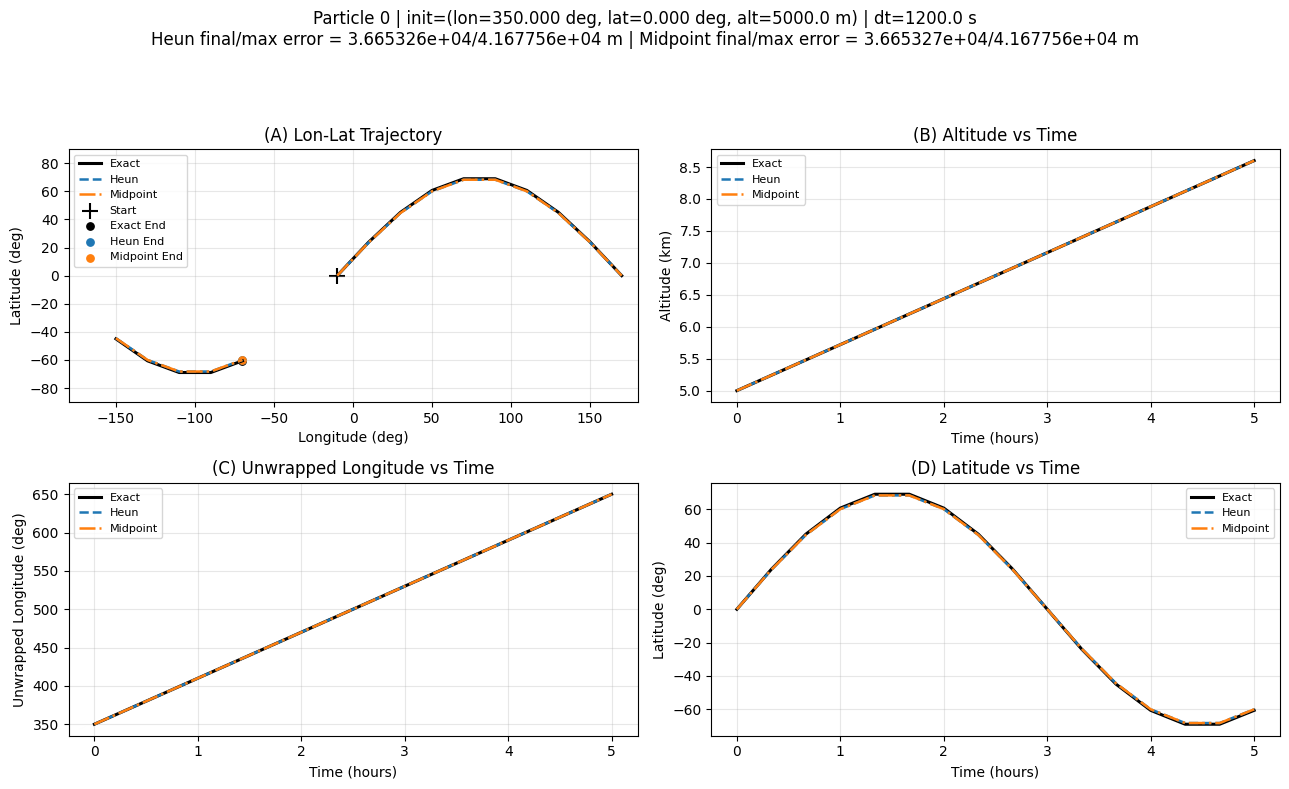

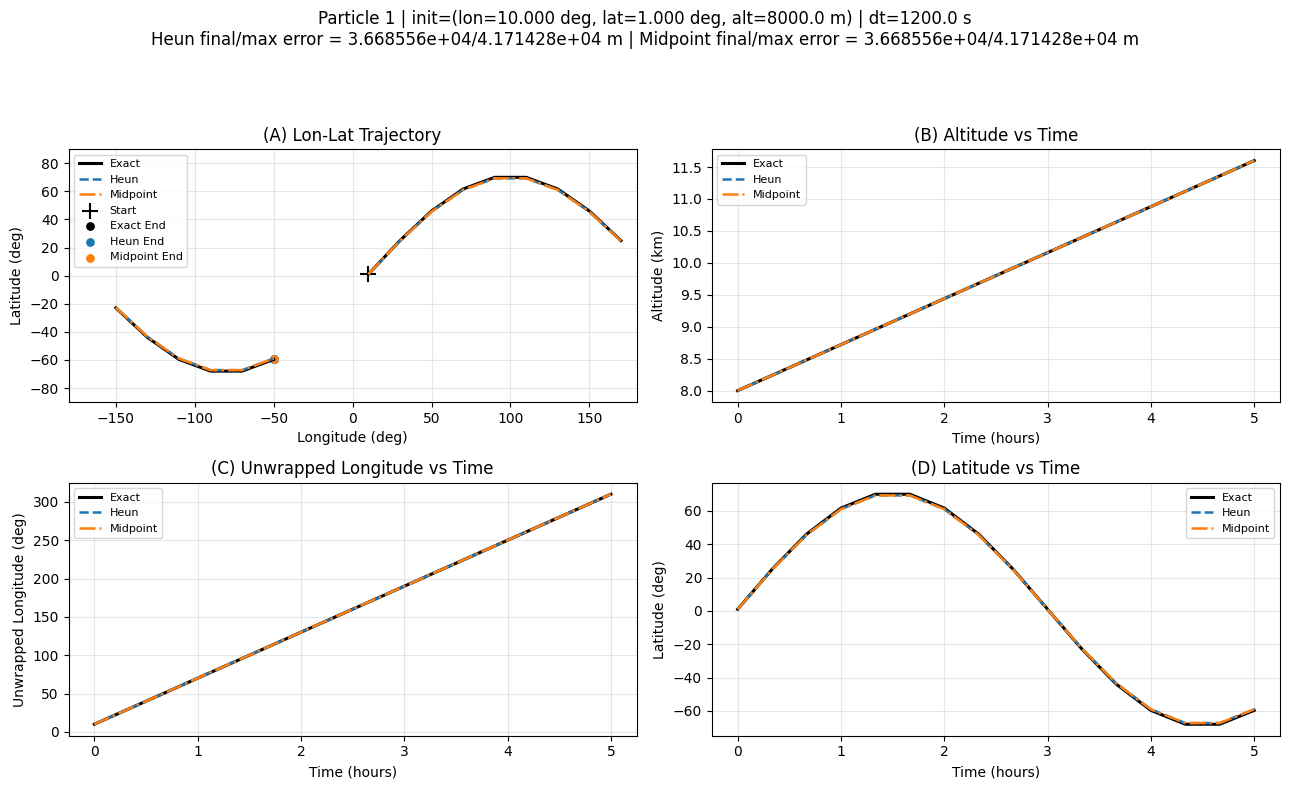

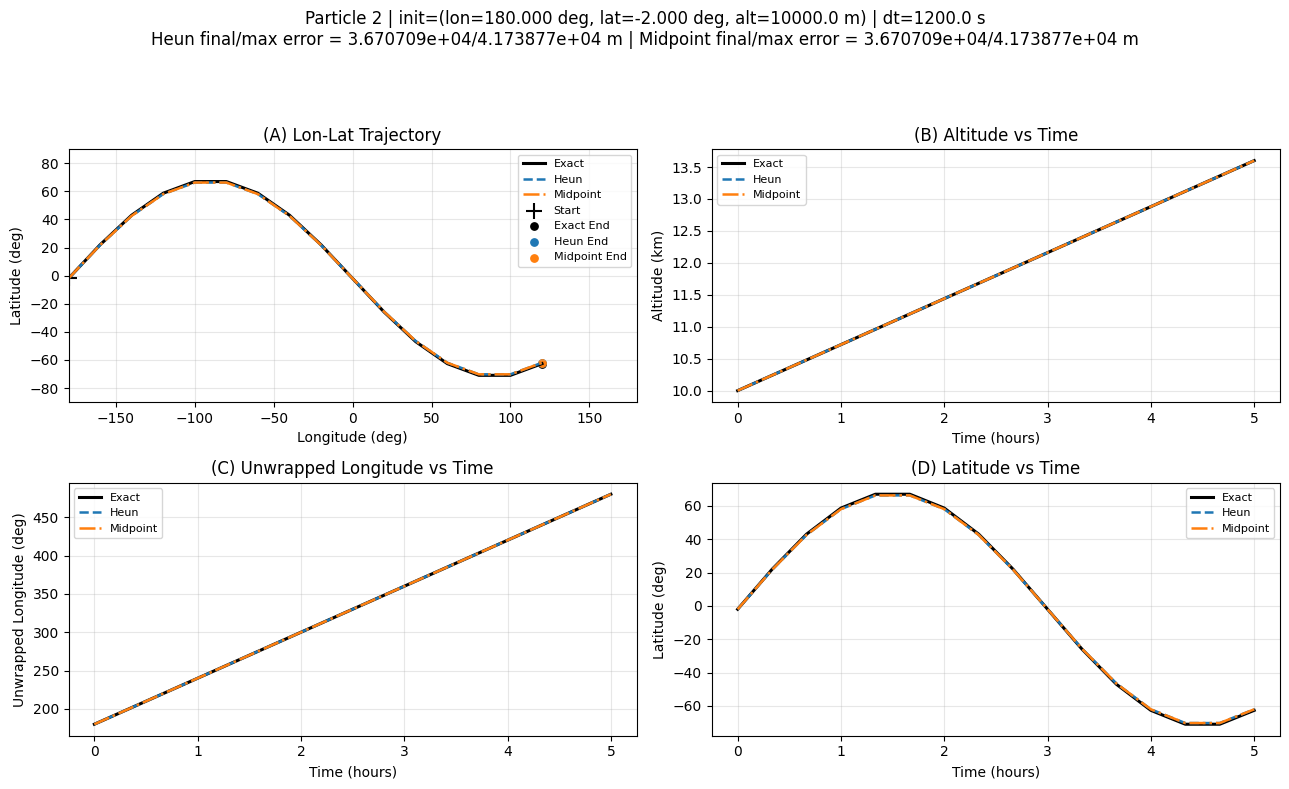

In [10]:
# ============================================================
# 12) Case1-Lat70: keep original Case1 unchanged, add a local high-lat visualization
# ============================================================

A_deg_local = 70.0
A_local = np.deg2rad(A_deg_local)
dt_local = 1200.0
t_end_local = t_end

time_local = make_time_grid(dt_local, t_end_local)


def exact_helix_lat70(t, lon0_deg, lat0_deg, alt0_m):
    """Local analytic trajectory for Case1-Lat70."""
    t = np.asarray(t, dtype=np.float64)
    lon = (lon0_deg + np.rad2deg(Omega * t)) % 360.0
    lat = lat0_deg + A_deg_local * np.sin(Omega * t)
    alt = alt0_m + W * t
    return lon, lat, alt


def build_wind_fields_lat70(time_s, alt_grid_local, lat_grid_local, lon_grid_local):
    """Local manufactured wind fields with latitude amplitude A_deg_local."""
    time_s = np.asarray(time_s, dtype=np.float64)
    alt_grid_local = np.asarray(alt_grid_local, dtype=np.float64)
    lat_grid_local = np.asarray(lat_grid_local, dtype=np.float64)
    lon_grid_local = np.asarray(lon_grid_local, dtype=np.float64)

    Tn = time_s.size
    Zn = alt_grid_local.size
    Yn = lat_grid_local.size
    Xn = lon_grid_local.size

    rho = (R + alt_grid_local)[:, None, None]  # (Z,1,1)

    lat_rad = np.deg2rad(lat_grid_local)[None, :, None]  # (1,Y,1)
    u_zy1 = rho * np.cos(lat_rad) * Omega  # (Z,Y,1)
    u_zyx = np.broadcast_to(u_zy1, (Zn, Yn, Xn))  # (Z,Y,X)

    u = np.empty((Tn, Zn, Yn, Xn), dtype=np.float64)
    u[:] = u_zyx[None, :, :, :]

    v = np.empty((Tn, Zn, Yn, Xn), dtype=np.float64)
    cos_term = np.cos(Omega * time_s)
    for it, c in enumerate(cos_term):
        v_z = (R + alt_grid_local) * (A_local * Omega * c)  # (Z,)
        v[it, :, :, :] = v_z[:, None, None]

    w = np.full((Tn, Zn, Yn, Xn), W, dtype=np.float64)
    return u, v, w


def _last_finite_local(arr):
    arr = np.asarray(arr, dtype=np.float64)
    idx = np.where(np.isfinite(arr))[0]
    if idx.size == 0:
        return np.nan
    return float(arr[idx[-1]])


def _max_finite_local(arr):
    arr = np.asarray(arr, dtype=np.float64)
    if not np.any(np.isfinite(arr)):
        return np.nan
    return float(np.nanmax(arr))


lon_grid_local = lon_grid
alt_grid_local = alt_grid
lat_grid_local = np.linspace(-80.0, 80.0, 641, dtype=np.float64)

lower_boundary_local = float(alt_grid_local.min())
upper_boundary_local = float(alt_grid_local.max())

u_local, v_local, w_local = build_wind_fields_lat70(time_local, alt_grid_local, lat_grid_local, lon_grid_local)

traj_heun_local = track_particles_heun(
    time=time_local,
    u_time_interp=u_local,
    v_time_interp=v_local,
    w_time_interp=w_local,
    need_track_initial_points=init_points,
    alt_grid_m=alt_grid_local,
    lat_grid=lat_grid_local,
    lon_grid=lon_grid_local,
    lower_boundary=lower_boundary_local,
    upper_boundary=upper_boundary_local,
    radius=R,
    verbose=False,
    w_positive_up=True,
    lon_mode=None,
    periodic_lon="auto",
)

traj_mid_local = track_particles_midpoint(
    time=time_local,
    u_time_interp=u_local,
    v_time_interp=v_local,
    w_time_interp=w_local,
    need_track_initial_points=init_points,
    alt_grid_m=alt_grid_local,
    lat_grid=lat_grid_local,
    lon_grid=lon_grid_local,
    lower_boundary=lower_boundary_local,
    upper_boundary=upper_boundary_local,
    radius=R,
    verbose=False,
    w_positive_up=True,
    lon_mode=None,
    periodic_lon="auto",
    picard_iters=3,
    picard_tol=None,
    use_slerp_midpoint=True,
)

if len(traj_heun_local) != len(time_local) - 1:
    raise ValueError("Case1-Lat70 Heun step length mismatch")
if len(traj_mid_local) != len(time_local) - 1:
    raise ValueError("Case1-Lat70 Midpoint step length mismatch")

compare_payload_local = {}
rows_local = []

for pid, init_point in enumerate(init_points):
    lon_ex, lat_ex, alt_ex = exact_helix_lat70(time_local, *init_point)
    exact_series = (
        np.asarray(lon_ex, dtype=np.float64),
        np.asarray(lat_ex, dtype=np.float64),
        np.asarray(alt_ex, dtype=np.float64),
    )

    heun_series = extract_particle_series(traj_heun_local, init_points, pid, include_initial=True)
    mid_series = extract_particle_series(traj_mid_local, init_points, pid, include_initial=True)

    if heun_series[0].shape[0] != time_local.shape[0]:
        raise ValueError(f"Case1-Lat70 Heun series length mismatch for pid={pid}")
    if mid_series[0].shape[0] != time_local.shape[0]:
        raise ValueError(f"Case1-Lat70 Midpoint series length mismatch for pid={pid}")

    heun_err = compute_path_error_m(heun_series, exact_series)
    mid_err = compute_path_error_m(mid_series, exact_series)

    metrics = {
        "heun_final_error_m": _last_finite_local(heun_err),
        "heun_max_error_m": _max_finite_local(heun_err),
        "midpoint_final_error_m": _last_finite_local(mid_err),
        "midpoint_max_error_m": _max_finite_local(mid_err),
    }

    compare_payload_local[pid] = {
        "init_point": init_point,
        "exact": exact_series,
        "heun": heun_series,
        "midpoint": mid_series,
        "heun_err": heun_err,
        "mid_err": mid_err,
        "metrics": metrics,
    }

    rows_local.append((pid, init_point, float(np.nanmin(lat_ex)), float(np.nanmax(lat_ex)), metrics))

print("\n=== Case1-Lat70 metrics (dt_local = {:.1f} s, t_end_local = {:.1f} h) ===".format(dt_local, t_end_local / 3600.0))
print(
    "{:<4s} {:>28s} {:>21s} {:>27s} {:>31s}".format(
        "pid",
        "init (lon, lat, alt_m)",
        "analytic lat min/max",
        "Heun final/max error (m)",
        "Midpoint final/max error (m)",
    )
)
for pid, init_point, lat_min, lat_max, m in rows_local:
    print(
        "{:<4d} ({:7.2f}, {:6.2f}, {:8.1f}) ({:8.3f}, {:8.3f}) {:>12.6e} / {:>12.6e} {:>12.6e} / {:>12.6e}".format(
            pid,
            float(init_point[0]),
            float(init_point[1]),
            float(init_point[2]),
            lat_min,
            lat_max,
            m["heun_final_error_m"],
            m["heun_max_error_m"],
            m["midpoint_final_error_m"],
            m["midpoint_max_error_m"],
        )
    )

sampled_peak = float(np.max(np.sin(Omega * time_local)) * A_deg_local)
print(
    "[Note] dt_local={:.0f}s uses discrete samples: sampled positive peak is about +{:.2f} deg; "
    "continuous target amplitude is +/-{:.2f} deg.".format(dt_local, sampled_peak, A_deg_local)
)

for pid in range(len(init_points)):
    payload = compare_payload_local[pid]
    plot_compare_particle(
        pid=pid,
        time_s=time_local,
        exact=payload["exact"],
        heun=payload["heun"],
        midpoint=payload["midpoint"],
        init_point=payload["init_point"],
        metrics=payload["metrics"],
    )

# optional cleanup of local large arrays

del u_local, v_local, w_local



=== Case1-Lat70 3D visualization run (enhanced scaling) ===
pid        init (lon, lat, alt_m)    Heun final/max error (m)    Midpoint final/max error (m)
0    ( 350.00,   0.00,   5000.0) 3.665326e+04 / 4.167756e+04 3.665327e+04 / 4.167756e+04


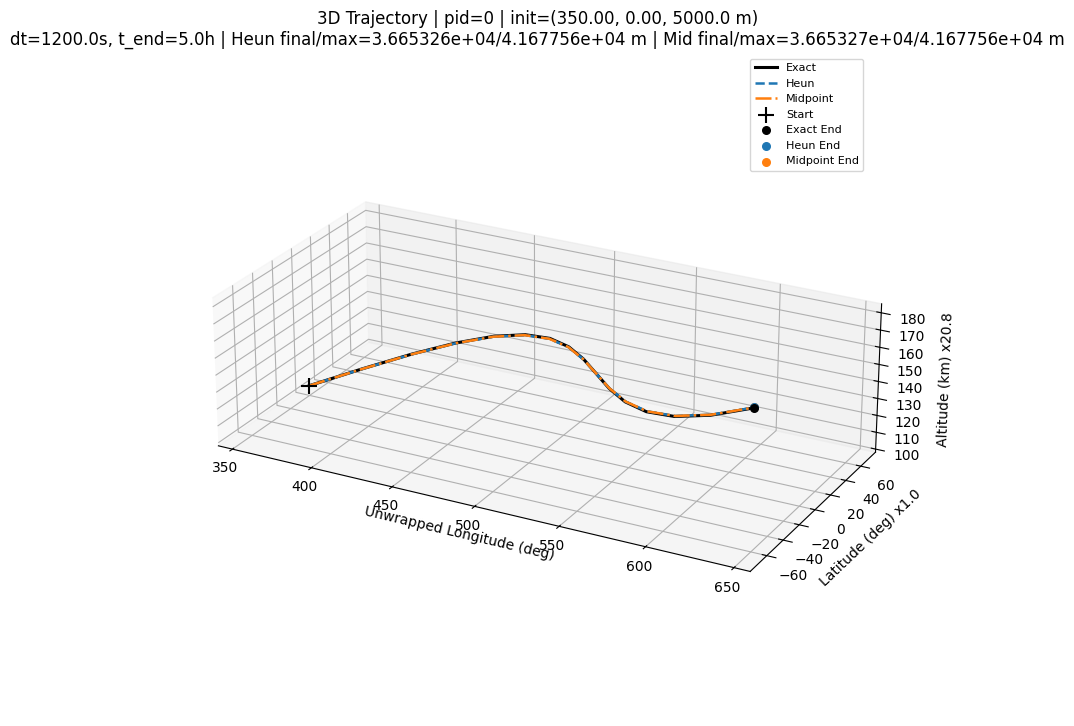

1    (  10.00,   1.00,   8000.0) 3.668556e+04 / 4.171428e+04 3.668556e+04 / 4.171428e+04


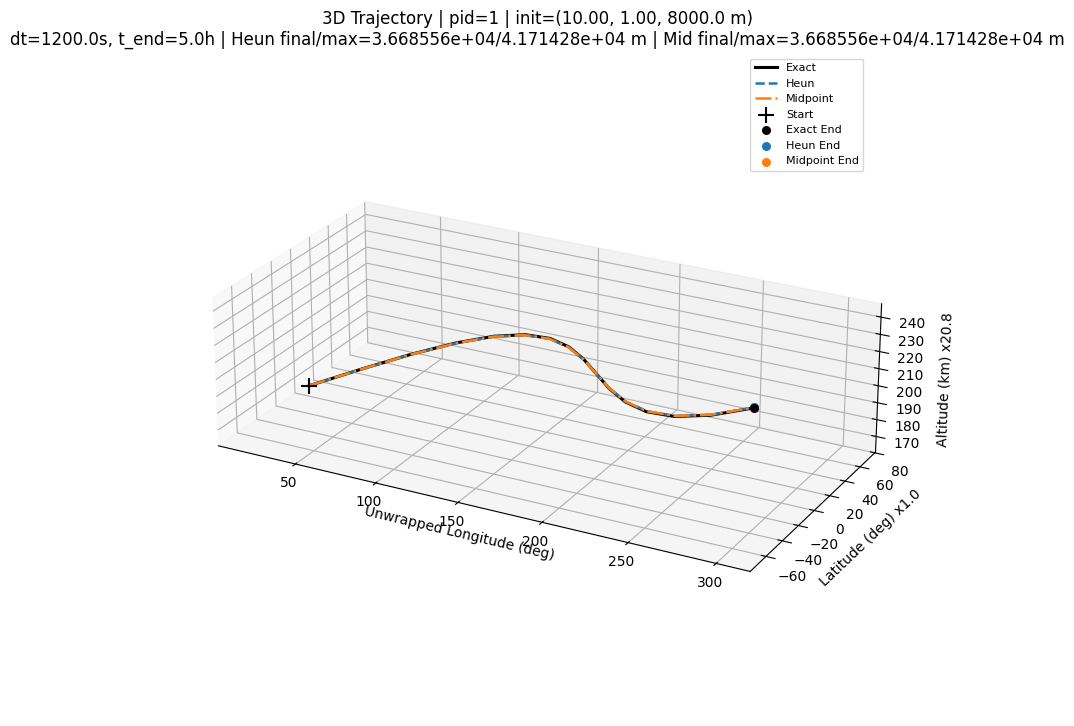

2    ( 180.00,  -2.00,  10000.0) 3.670709e+04 / 4.173877e+04 3.670709e+04 / 4.173877e+04


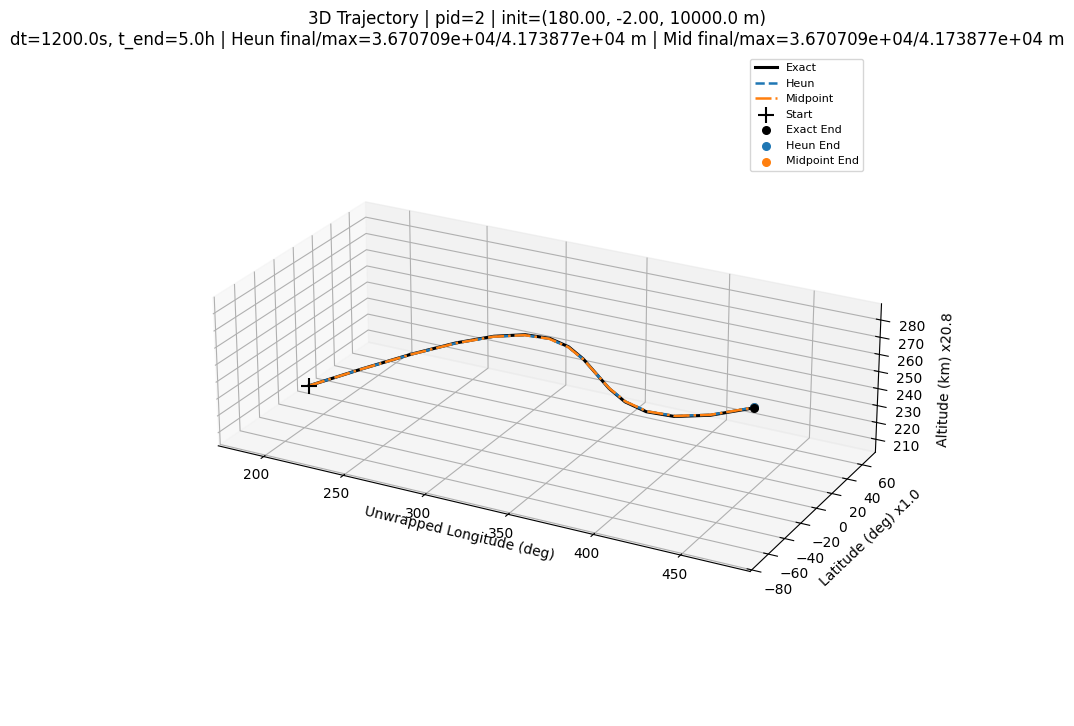

In [11]:
# ============================================================
# 13) Case1-Lat70: 3D visualization (new cell, no changes to previous code)
# ============================================================

required_symbols = [
    "time_local",
    "init_points",
    "compare_payload_local",
    "plot_compare_particle_3d",
]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required objects for Case1-Lat70 3D visualization: "
        + ", ".join(missing)
        + ". Please run previous cells (especially Case1-Lat70 cell) first."
    )

if len(compare_payload_local) != len(init_points):
    raise ValueError(
        "compare_payload_local size mismatch with init_points; "
        "please rerun the Case1-Lat70 cell before this 3D cell."
    )

print("\n=== Case1-Lat70 3D visualization run (enhanced scaling) ===")
print(
    "{:<4s} {:>28s} {:>27s} {:>31s}".format(
        "pid",
        "init (lon, lat, alt_m)",
        "Heun final/max error (m)",
        "Midpoint final/max error (m)",
    )
)

for pid in range(len(init_points)):
    payload = compare_payload_local[pid]
    m = payload["metrics"]
    p0 = payload["init_point"]

    print(
        "{:<4d} ({:7.2f}, {:6.2f}, {:8.1f}) {:>12.6e} / {:>12.6e} {:>12.6e} / {:>12.6e}".format(
            pid,
            float(p0[0]),
            float(p0[1]),
            float(p0[2]),
            m["heun_final_error_m"],
            m["heun_max_error_m"],
            m["midpoint_final_error_m"],
            m["midpoint_max_error_m"],
        )
    )

    plot_compare_particle_3d(
        pid=pid,
        time_s=time_local,
        exact=payload["exact"],
        heun=payload["heun"],
        midpoint=payload["midpoint"],
        init_point=payload["init_point"],
        metrics=payload["metrics"],
        scaling="enhanced",
    )


In [13]:
m["heun_final_error_m"] / 1000

36.70709052592327

In [14]:
m['midpoint_final_error_m']/1000

36.70709089134763